<a href="https://colab.research.google.com/github/cchasse8/sports-nlp-forecasting/blob/main/darts_forecasting_nlp_v5_NKE_GitHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Darts Forecasting NLP V5 - NKE

A ticker-agnostic forecasting and backtesting pipeline for sports-industry stocks.
Combines price/technical features with three NLP signal streams:

1. **General news sentiment** — GDELT headline sentiment (free, no API key required)  
2. **Sports-specific news** — keyword-filtered sports event headlines via GDELT  
3. **Earnings call sentiment** — SEC EDGAR transcript filings via `sec-edgar-downloader`

**Prediction horizon:** 1-day forward log return  
**Model:** RandomForest via Darts `SKLearnModel`


In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Installing dependencies...")
    !pip install -q "numpy>=1.26,<2.0" --quiet 2>&1 | tail -1
    !pip install -q "darts" "vectorbt" "yfinance" "pyarrow" --quiet
    !pip install -q "transformers>=4.30" "sec-edgar-downloader" "requests" "pytorch-lightning" "pytrends" --quiet
    print("✓ Done. Now go to Runtime > Restart Session, then Run All.")
    print("⚠️ NOTE: Colab resets /content/ each session.")
    print("   Mount Google Drive (next cell) to persist caches.")
else:
    print("Running locally — skipping install.")

Installing dependencies...
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
✓ Done. Now go to Runtime > Restart Session, then Run All.
⚠️ NOTE: Colab resets /content/ each session.
   Mount Google Drive (next cell) to persist caches.


In [ ]:
import sys, os
IN_COLAB = "google.colab" in sys.modules

CACHE_DIR = "."  # default: current directory (lost on Colab reset)

if IN_COLAB:
    use_drive = True   # set False to skip Drive
    if use_drive:
        from google.colab import drive
        drive.mount("/content/drive")
        CACHE_DIR = "/content/drive/MyDrive/stock_nlp_cache"
        os.makedirs(CACHE_DIR, exist_ok=True)
        print(f"✓ Cache directory: {CACHE_DIR}")
    else:
        print("Drive not mounted — caches stored in /content/ (session only)")
else:
    print(f"Running locally — caches stored in: {os.path.abspath(CACHE_DIR)}")

Mounted at /content/drive
✓ Cache directory: /content/drive/MyDrive/stock_nlp_cache


In [ ]:
# ─────────────────────────────────────────────
# CONFIG — change these values to switch stocks
# ─────────────────────────────────────────────

TICKER      = "NKE"          # Yahoo Finance ticker (e.g. "MSGS", "MANU", "FWONK", "DKNG")
COMPANY     = "Nike"         # Plain-English company name for news queries
START_DATE  = "2020-01-01"
END_DATE    = "2023-12-31"
INIT_CASH   = 10_000
TRAIN_SPLIT = 0.8

FORECAST_HORIZON       = 1   # Days ahead to predict (next trading day)
SIGNAL_THRESHOLD_MULT  = 0.5 # Signal threshold = multiplier × forecast std dev

# Sports keywords — news mentioning these near COMPANY are flagged as sports events
SPORTS_KEYWORDS = [
    "championship", "playoff", "sponsorship", "jersey", "endorsement",
    "athlete", "league", "tournament", "Super Bowl", "NBA Finals",
    "World Cup", "Olympics",
]


# Google Trends — search queries that capture sports attention for this company
# Each query is fetched separately then averaged to a single daily score
TRENDS_QUERIES = [
    f"{COMPANY} sponsor",
    f"{COMPANY} athlete",
    f"{COMPANY} sports",
]

# SEC EDGAR — your email is required by EDGAR's fair-use policy (not stored anywhere)
EDGAR_EMAIL = "your_email@example.com"   # <-- replace with your email

# Derived — do not edit (CACHE_DIR set in Drive mount cell above)
try:
    _cd = CACHE_DIR
except NameError:
    _cd = "."
CACHE_PATH     = os.path.join(_cd, f"{TICKER}_{START_DATE[:4]}_{END_DATE[:4]}.parquet")
NEWS_CACHE     = os.path.join(_cd, f"{TICKER}_gdelt_sentiment.parquet")
SPORTS_CACHE   = os.path.join(_cd, f"{TICKER}_sports_sentiment.parquet")
EARNINGS_CACHE  = os.path.join(_cd, f"{TICKER}_earnings_sentiment.parquet")
TRENDS_CACHE    = os.path.join(_cd, f"{TICKER}_trends_sentiment.parquet")

print(f"Config loaded: {TICKER} ({COMPANY}) | {START_DATE} → {END_DATE}")
print(f"Forecast horizon: {FORECAST_HORIZON} trading day")

Config loaded: NKE (Nike) | 2020-01-01 → 2023-12-31
Forecast horizon: 1 trading day


In [ ]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────

import ast, os, re, sys, time, warnings
from typing import List, Optional
import numpy as np
import pandas as pd
import requests
import yfinance as yf

warnings.filterwarnings("ignore")

from darts import TimeSeries
from darts.models import SKLearnModel
from darts.dataprocessing.transformers import MissingValuesFiller

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

import vectorbt as vbt

# Sentiment model — FinBERT is fine-tuned on financial text
from transformers import pipeline as hf_pipeline

print("\u2713 Imports successful")
print("Loading FinBERT sentiment model (downloads ~500 MB on first run)...")
_sentiment_pipe = hf_pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    truncation=True,
    max_length=512,
    device=-1,           # CPU; set to 0 for GPU
)
print("\u2713 FinBERT ready")


def score_texts(texts: List[str]) -> List[float]:
    """Return a float sentiment score per text: +1 (positive) … -1 (negative)."""
    if not texts:
        return []
    label_map = {"positive": 1.0, "negative": -1.0, "neutral": 0.0}
    results = _sentiment_pipe(texts, batch_size=16)
    return [label_map.get(r["label"].lower(), 0.0) * r["score"] for r in results]

✓ Imports successful
Loading FinBERT sentiment model (downloads ~500 MB on first run)...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ FinBERT ready


In [ ]:
# ─────────────────────────────────────────────
# 1. LOAD & PREPARE PRICE DATA
# ─────────────────────────────────────────────

if os.path.exists(CACHE_PATH):
    print(f"Loading price data from cache: {CACHE_PATH}")
    df_raw = pd.read_parquet(CACHE_PATH)
else:
    print(f"Downloading {TICKER} from Yahoo Finance...")
    df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE)
    df_raw.to_parquet(CACHE_PATH)
    print(f"Saved to cache: {CACHE_PATH}")

# Flatten multi-level yfinance columns
def _flatten_col(c):
    if isinstance(c, tuple) and len(c) > 0:
        return c[0]
    if isinstance(c, str) and c.startswith("(") and c.endswith(")"):
        try:
            t = ast.literal_eval(c)
            if isinstance(t, tuple):
                return t[0]
        except (ValueError, SyntaxError):
            pass
    return c

base_series = TimeSeries.from_dataframe(
    df_raw,
    value_cols=["Close", "High", "Low", "Open", "Volume"],
    fill_missing_dates=True,
    freq="B",
)
base_series = MissingValuesFiller().transform(base_series)

vals = base_series.values()
idx  = base_series.time_index
cols = [_flatten_col(c) for c in base_series.components]
df   = pd.DataFrame(vals, index=idx, columns=cols)

# ── Technical features ──────────────────────────────────────────────────────
df["LogReturn"]    = np.log(df["Close"]).diff()
df["RangePct"]     = (df["High"] - df["Low"]) / df["Close"]
df["OC_Pct"]       = (df["Close"] - df["Open"]) / df["Open"]
df["LogVol"]       = np.log(df["Volume"].replace(0, np.nan))
df["Ret_5d_mean"]  = df["LogReturn"].rolling(5).mean()
df["Ret_20d_mean"] = df["LogReturn"].rolling(20).mean()
df["Ret_5d_vol"]   = df["LogReturn"].rolling(5).std()
df["Ret_20d_vol"]  = df["LogReturn"].rolling(20).std()

# ── 1-day forward return (prediction target) ────────────────────────────────
df["FwdReturn_1d"] = df["LogReturn"].shift(-FORECAST_HORIZON)


PRICE_FEATURE_COLS = [
    "RangePct", "OC_Pct", "LogVol",
    "Ret_5d_mean", "Ret_20d_mean",
    "Ret_5d_vol",  "Ret_20d_vol",
]

df = df.dropna(subset=["LogReturn"] + PRICE_FEATURE_COLS)
print(f"Price data ready: {len(df)} trading days | {df.index[0].date()} → {df.index[-1].date()}")
df.tail(3)

Loading price data from cache: /content/drive/MyDrive/stock_nlp_cache/NKE_2020_2023.parquet
Price data ready: 1022 trading days | 2020-01-30 → 2023-12-29


,Close,High,Low,Open,Volume,LogReturn,RangePct,OC_Pct,LogVol,Ret_5d_mean,Ret_20d_mean,Ret_5d_vol,Ret_20d_vol,FwdReturn_1d
Date,,,,,,,,,,,,,,
2023-12-27,102.227371,103.620556,101.960186,103.381997,10157900.0,-0.008273,0.016242,-0.011169,16.133762,-0.025059,-0.001322,0.056677,0.031207,0.015652
2023-12-28,103.840042,104.393501,101.922024,102.303720,9352900.0,0.015652,0.023801,0.015017,16.051197,-0.023732,-0.000494,0.057742,0.031437,-0.002300
2023-12-29,103.601486,104.927875,103.143449,103.973638,7667500.0,-0.002300,0.017224,-0.003579,15.852501,0.000979,-0.002212,0.008859,0.030490,NaN


## 2. NLP Feature Engineering

### 2a. General News Sentiment (GDELT)

GDELT is a free, open dataset that indexes global news in near real-time.  
We query its API for headlines mentioning the company and score them with FinBERT.  
Results are aggregated to **daily sentiment scores** and cached locally.


In [ ]:
# ─────────────────────────────────────────────
# 2a. GDELT NEWS SENTIMENT
# ─────────────────────────────────────────────

GDELT_URL = "https://api.gdeltproject.org/api/v2/doc/doc"

def fetch_gdelt_headlines(query: str, start: str, end: str,
                          max_records: int = 250) -> pd.DataFrame:
    """
    Query GDELT DocAPI for news headlines.
    start / end: 'YYYYMMDDHHMMSS' format expected by GDELT.
    Returns DataFrame with columns [date, title, url].
    Raises a RateLimitError on 429 so the caller can handle backoff.
    """
    params = {
        "query": query,
        "mode":  "ArtList",
        "maxrecords": max_records,
        "startdatetime": start,
        "enddatetime":   end,
        "format": "json",
    }
    try:
        resp = requests.get(GDELT_URL, params=params, timeout=30)
        if resp.status_code == 429:
            # Raise explicitly so fetch_sentiment_in_chunks can catch and sleep
            raise requests.exceptions.HTTPError(
                f"429 Rate Limited by GDELT — will retry after backoff"
            )
        resp.raise_for_status()
        data = resp.json()
        articles = data.get("articles", [])
        rows = []
        for a in articles:
            date_str = a.get("seendate", "")
            try:
                date = pd.to_datetime(date_str[:8], format="%Y%m%d")
            except Exception:
                continue
            rows.append({"date": date, "title": a.get("title", ""), "url": a.get("url", "")})
        return pd.DataFrame(rows)
    except requests.exceptions.HTTPError as e:
        if "429" in str(e):
            raise   # re-raise 429 so caller handles backoff
        print(f"  GDELT HTTP error: {e}")
        return pd.DataFrame(columns=["date", "title", "url"])
    except Exception as e:
        print(f"  GDELT request failed: {e}")
        return pd.DataFrame(columns=["date", "title", "url"])


def build_daily_sentiment(df_news: pd.DataFrame) -> pd.Series:
    """Score each headline with FinBERT; return mean daily score."""
    if df_news.empty:
        return pd.Series(dtype=float)

    titles = df_news["title"].fillna("").tolist()
    scores = score_texts(titles)
    df_news = df_news.copy()
    df_news["score"] = scores
    daily = df_news.groupby("date")["score"].mean()
    daily.index = pd.DatetimeIndex(daily.index)
    return daily


def fetch_sentiment_in_chunks(query: str, start_date: str, end_date: str,
                               chunk_days: int = 365) -> pd.Series:
    """
    Fetch GDELT sentiment in annual chunks with robust 429 backoff.
    On a 429, waits with exponential backoff (60s, 120s, 240s, 480s, 960s)
    before retrying — much longer than GDELT's typical cooldown window.
    """
    all_chunks = []
    periods = pd.date_range(start=start_date, end=end_date, freq=f"{chunk_days}D")
    if periods[-1] < pd.Timestamp(end_date):
        periods = periods.append(pd.DatetimeIndex([end_date]))

    all_scores = []
    for i in range(len(periods) - 1):
        s = periods[i].strftime("%Y%m%d") + "000000"
        e = periods[i + 1].strftime("%Y%m%d") + "000000"
        print(f"  Fetching GDELT: {s[:8]} → {e[:8]}", end="\r")

        chunk = pd.DataFrame(columns=["date", "title", "url"])
        for attempt in range(6):
            try:
                chunk = fetch_gdelt_headlines(query, s, e)
                all_chunks.append(chunk)
                break   # success — exit retry loop
            except requests.exceptions.HTTPError as e429:
                # Exponential backoff: 60, 120, 240, 480, 960 seconds
                wait = 60 * (2 ** attempt)
                print(f"\n  GDELT 429 — waiting {wait}s before retry "
                      f"{attempt + 1}/5...")
                time.sleep(wait)
                if attempt == 5:
                    print("  Max retries reached — skipping this chunk.")
                    all_chunks.append(chunk)

        if not chunk.empty:
            all_scores.append(build_daily_sentiment(chunk))

        # Polite delay between every chunk regardless of success
        time.sleep(30)

    print()
    if not all_scores:
        return pd.Series(dtype=float, name="news_sentiment")
    combined = pd.concat(all_scores)
    combined = combined[~combined.index.duplicated(keep="first")].sort_index()
    combined.name = "news_sentiment"

    global _all_headlines
    _all_headlines = (pd.concat(all_chunks, ignore_index=True)
                      if all_chunks
                      else pd.DataFrame(columns=["date", "title", "url"]))

    return combined


# ── Load or build general news sentiment ────────────────────────────────────
if os.path.exists(NEWS_CACHE):
    print(f"Loading news sentiment from cache: {NEWS_CACHE}")
    df_news_sent = pd.read_parquet(NEWS_CACHE)
    news_daily = df_news_sent["news_sentiment"]
    news_daily.index = pd.DatetimeIndex(news_daily.index)
else:
    print(f"Fetching GDELT headlines for '{COMPANY}'...")
    news_daily = fetch_sentiment_in_chunks(
      query=COMPANY,
      start_date=START_DATE,
      end_date=END_DATE,
      chunk_days=365,
)
    pd.DataFrame({"news_sentiment": news_daily}).to_parquet(NEWS_CACHE)
    _all_headlines.to_parquet(NEWS_CACHE.replace(".parquet", "_raw.parquet"))
    print(f"Saved to cache: {NEWS_CACHE}")

print(f"News sentiment: {len(news_daily)} days with scores | "
      f"mean={news_daily.mean():.3f}  std={news_daily.std():.3f}")


Loading news sentiment from cache: /content/drive/MyDrive/stock_nlp_cache/NKE_gdelt_sentiment.parquet
News sentiment: 233 days with scores | mean=-0.011  std=0.170


### 2b. Sports Event Sentiment

We re-query GDELT with the company name **plus** a sports keyword filter.  
This isolates articles about sponsorships, athlete endorsements, championship outcomes, etc.  
The idea: positive sports exposure → brand lift → short-term stock bump.


In [ ]:

# ─────────────────────────────────────────────
# 2b. SPORTS-SPECIFIC SENTIMENT
# Derived from already-fetched general news — no extra API calls
# ─────────────────────────────────────────────

if os.path.exists(SPORTS_CACHE):
    print(f"Loading sports sentiment from cache: {SPORTS_CACHE}")
    df_sports_sent = pd.read_parquet(SPORTS_CACHE)
    sports_daily = df_sports_sent["sports_sentiment"]
    sports_daily.index = pd.DatetimeIndex(sports_daily.index)
else:
    print("Deriving sports sentiment from general news headlines...")

    raw_cache_path = NEWS_CACHE.replace(".parquet", "_raw.parquet")

    if not os.path.exists(raw_cache_path):
        print("  No raw headline cache found — re-running general news fetch...")
        # Re-fetch headlines and save both sentiment + raw cache
        news_daily = fetch_sentiment_in_chunks(
            query=COMPANY,
            start_date=START_DATE,
            end_date=END_DATE,
            chunk_days=365,
        )
        pd.DataFrame({"news_sentiment": news_daily}).to_parquet(NEWS_CACHE)
        _all_headlines.to_parquet(raw_cache_path)
        print(f"  Raw headline cache saved: {raw_cache_path}")

    df_raw_headlines = pd.read_parquet(raw_cache_path)

    kw_pattern = "|".join(SPORTS_KEYWORDS)
    sports_mask = df_raw_headlines["title"].str.contains(
        kw_pattern, case=False, na=False
    )
    df_sports_headlines = df_raw_headlines[sports_mask].copy()
    print(f"  {sports_mask.sum()} of {len(df_raw_headlines)} headlines matched sports keywords")

    if df_sports_headlines.empty:
        print("  No sports headlines found — sports_sentiment will be all zeros")
        sports_daily = pd.Series(0.0, index=news_daily.index, name="sports_sentiment")
    else:
        sports_daily = build_daily_sentiment(df_sports_headlines)
        sports_daily.name = "sports_sentiment"

    pd.DataFrame({"sports_sentiment": sports_daily}).to_parquet(SPORTS_CACHE)
    print(f"Saved to cache: {SPORTS_CACHE}")

Loading sports sentiment from cache: /content/drive/MyDrive/stock_nlp_cache/NKE_sports_sentiment.parquet


### 2d. Google Trends Sports Attention Signal

`pytrends` pulls weekly Google search interest (0–100 scale) for sport-related queries about the company.  
High search volume around events like sponsorship announcements or athlete deals reflects  
public attention that can precede stock moves.  
Weekly data is resampled to daily via forward-fill, then normalised to a 0–1 range.

> **Note:** Google Trends throttles requests. The first run fetches one query at a time  
> with a sleep between each. Results are cached locally.


In [ ]:
# ─────────────────────────────────────────────
# 2d. GOOGLE TRENDS SPORTS ATTENTION SIGNAL
# ─────────────────────────────────────────────

def fetch_google_trends(queries: list, start_date: str, end_date: str,
                        cache_path: str) -> pd.Series:
    """
    Fetch Google Trends interest-over-time for a list of queries.
    Returns a daily Series normalised to [0, 1], forward-filled across
    the full date range. Results are cached to avoid re-fetching.
    """
    if os.path.exists(cache_path):
        print(f"Loading Google Trends from cache: {cache_path}")
        df_trends = pd.read_parquet(cache_path)
        trends_daily = df_trends["trends_score"]
        trends_daily.index = pd.DatetimeIndex(trends_daily.index)
        return trends_daily

    try:
        from pytrends.request import TrendReq
    except ImportError:
        print("pytrends not installed — run: pip install pytrends")
        bday_index = pd.date_range(start=start_date, end=end_date, freq="B")
        return pd.Series(0.0, index=bday_index, name="trends_score")

    # Google Trends timeframe string: "YYYY-MM-DD YYYY-MM-DD"
    timeframe = f"{start_date} {end_date}"
    pt = TrendReq(hl="en-US", tz=360)

    all_series = []
    for query in queries:
        print(f"  Fetching Google Trends: '{query}'...")
        try:
            pt.build_payload([query], cat=0, timeframe=timeframe, geo="", gprop="")
            df_q = pt.interest_over_time()
            if df_q.empty or query not in df_q.columns:
                print(f"  No data returned for '{query}' — skipping")
                continue
            s = df_q[query].astype(float)
            s.index = pd.DatetimeIndex(s.index)
            all_series.append(s)
            time.sleep(5)  # respect rate limits
        except Exception as e:
            print(f"  Trends fetch failed for '{query}': {e}")
            continue

    if not all_series:
        print("  No Trends data retrieved — trends_score will be all zeros")
        bday_index = pd.date_range(start=start_date, end=end_date, freq="B")
        trends_daily = pd.Series(0.0, index=bday_index, name="trends_score")
        pd.DataFrame({"trends_score": trends_daily}).to_parquet(cache_path)
        return trends_daily

    # Average across all queries, normalise to [0, 1]
    combined = pd.concat(all_series, axis=1).mean(axis=1)
    max_val = combined.max()
    if max_val > 0:
        combined = combined / max_val
    combined.name = "trends_score"

    # Resample from weekly to daily via forward-fill
    bday_index = pd.date_range(start=start_date, end=end_date, freq="B")
    trends_daily = combined.reindex(bday_index, method="ffill").fillna(method="bfill").fillna(0.0)
    trends_daily.name = "trends_score"

    pd.DataFrame({"trends_score": trends_daily}).to_parquet(cache_path)
    print(f"  Saved to cache: {cache_path}")
    return trends_daily


trends_daily = fetch_google_trends(
    queries=TRENDS_QUERIES,
    start_date=START_DATE,
    end_date=END_DATE,
    cache_path=TRENDS_CACHE,
)
print(f"Google Trends: {len(trends_daily)} days | "
      f"mean={trends_daily.mean():.3f}  max={trends_daily.max():.3f}")


Loading Google Trends from cache: /content/drive/MyDrive/stock_nlp_cache/NKE_trends_sentiment.parquet
Google Trends: 1043 days | mean=0.578  max=1.000


### 2c. Earnings Call Transcript Sentiment (SEC EDGAR)

`sec-edgar-downloader` pulls 10-Q and 10-K filings from EDGAR.  
We extract the **Management Discussion & Analysis (MD&A)** section and score it  
with FinBERT. Each filing date gets a sentiment score; between filings the  
score is **forward-filled** so every trading day has a value.

> **Note:** EDGAR throttles downloads. The first run takes ~2–5 minutes  
> per filing depending on your connection. Results are cached locally.


In [ ]:
# ─────────────────────────────────────────────
# 2c. EARNINGS CALL / 10-Q SENTIMENT (SEC EDGAR)
# ─────────────────────────────────────────────

import glob

def download_edgar_filings(ticker: str, email: str,
                            form_types=("10-Q", "10-K"),
                            start_date="2019-01-01", end_date="2024-01-01"):
    try:
        from sec_edgar_downloader import Downloader
    except ImportError:
        print("sec-edgar-downloader not installed.")
        return []

    try:
        dl = Downloader("research", email)
    except TypeError:
        dl = Downloader(company_name="research", email_address=email)

    for form in form_types:
        try:
            dl.get(form, ticker, after=start_date, before=end_date)
        except Exception as e:
            print(f"  Download error ({form}): {e}")

    filings = []
    base_dir = os.path.join("sec-edgar-filings", ticker.upper())
    print(f"  Looking for filings in: {os.path.abspath(base_dir)}")

    for form in form_types:
        form_dir = os.path.join(base_dir, form)
        if not os.path.exists(form_dir):
            print(f"  Directory not found: {form_dir}")
            continue
        subdirs = sorted(os.listdir(form_dir))
        print(f"  Found {len(subdirs)} folders under {form}: {subdirs[:3]}...")

        for folder in subdirs:
            folder_path  = os.path.join(form_dir, folder)
            txt_files    = glob.glob(os.path.join(folder_path, "**", "*.txt"), recursive=True)
            if not txt_files:
                continue

            # ── Fix 1: parse date from file header, not folder name ──────────
            filing_date  = None
            for fpath in txt_files:
                try:
                    with open(fpath, "r", encoding="utf-8", errors="ignore") as fh:
                        head = fh.read(2000)
                    match = re.search(r"FILED AS OF DATE:\s*(\d{8})", head)
                    if match:
                        filing_date = pd.to_datetime(match.group(1), format="%Y%m%d")
                        break
                except Exception:
                    continue

            if filing_date is None:
                # Last resort: file modification time
                filing_date = pd.Timestamp.fromtimestamp(os.path.getmtime(txt_files[0]))

            filings.append((filing_date, txt_files[0]))

    return sorted(filings, key=lambda x: x[0])


def extract_mda_text(filepath: str, max_chars: int = 4000) -> str:
    try:
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
    except Exception:
        return ""

    # Extract main filing body from SGML wrapper
    text_match = re.search(r"<TEXT>(.*?)</TEXT>", text, re.DOTALL | re.IGNORECASE)
    if text_match:
        text = text_match.group(1)

    # Strip HTML/SGML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # ── Fix: decode HTML entities before scoring ─────────────────────────────
    import html
    text = html.unescape(text)

    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # ── Fix: skip past the table of contents to the real MD&A section ────────
    # The TOC has a short mention; the real section is much longer.
    # Find ALL occurrences and take the last one before financial tables.
    mda_pattern = re.compile(
        r"management.{0,30}discussion.{0,30}analysis",
        re.IGNORECASE,
    )
    matches = list(mda_pattern.finditer(text))

    if len(matches) >= 2:
        # Second match is usually the actual section header, skip the TOC
        start = matches[1].start()
    elif len(matches) == 1:
        start = matches[0].start()
    else:
        # No MD&A found — take a middle chunk to avoid boilerplate header
        start = len(text) // 4

    snippet = text[start: start + max_chars]
    return snippet.strip()


# ── Load or build earnings sentiment ────────────────────────────────────────
if os.path.exists(EARNINGS_CACHE):
    print(f"Loading earnings sentiment from cache: {EARNINGS_CACHE}")
    df_earn = pd.read_parquet(EARNINGS_CACHE)
else:
    print(f"Downloading SEC EDGAR filings for {TICKER}...")
    print("  (This may take several minutes on first run)")
    filings = download_edgar_filings(
        ticker=TICKER,
        email=EDGAR_EMAIL,
        start_date=str(int(START_DATE[:4]) - 1) + "-01-01",
        end_date=END_DATE,
    )
    print(f"  Found {len(filings)} filings")

    rows = []
    for filing_date, path in filings:
        text = extract_mda_text(path)
        if not text:
            continue
        score = score_texts([text])[0]
        rows.append({"date": filing_date, "earnings_sentiment": score})
        print(f"  Scored filing {filing_date.date()}: {score:+.3f}")

    # Handle case where no filings were found or scored
    if rows:
        df_earn = pd.DataFrame(rows).set_index("date")
        df_earn.index = pd.DatetimeIndex(df_earn.index)
    else:
        print("  No filings scored — earnings_sentiment will be all zeros")
        bday_index = pd.date_range(start=START_DATE, end=END_DATE, freq="B")
        df_earn = pd.DataFrame(
            {"earnings_sentiment": 0.0},
            index=bday_index
        )

    df_earn.to_parquet(EARNINGS_CACHE)
    print(f"Saved to cache: {EARNINGS_CACHE}")

# Forward-fill earnings sentiment to every business day in range
bday_index = pd.date_range(start=START_DATE, end=END_DATE, freq="B")
earnings_daily = df_earn["earnings_sentiment"].reindex(bday_index, method="ffill").fillna(0.0)
earnings_daily.name = "earnings_sentiment"

print(f"Earnings sentiment: {len(df_earn)} filings scored | "
      f"forward-filled to {earnings_daily.notna().sum()} trading days")

Loading earnings sentiment from cache: /content/drive/MyDrive/stock_nlp_cache/NKE_earnings_sentiment.parquet
Earnings sentiment: 20 filings scored | forward-filled to 1043 trading days


## 3. Merge All Features

In [ ]:
# ─────────────────────────────────────────────
# 3. MERGE PRICE + SENTIMENT FEATURES
# ─────────────────────────────────────────────

# Align all sentiment series to trading-day index
df["news_sentiment"]     = news_daily.reindex(df.index, method="ffill").fillna(0.0)
df["sports_sentiment"]   = sports_daily.reindex(df.index, method="ffill").fillna(0.0)
df["earnings_sentiment"] = earnings_daily.reindex(df.index, method="ffill").fillna(0.0)
df["trends_score"]       = trends_daily.reindex(df.index, method="ffill").fillna(0.0)

# Rolling smoothed versions (5-day EMA) to reduce noise — lookback window, not horizon
df["news_ema5"]     = df["news_sentiment"].ewm(span=5, adjust=False).mean()
df["sports_ema5"]   = df["sports_sentiment"].ewm(span=5, adjust=False).mean()
df["earnings_ema5"] = df["earnings_sentiment"].ewm(span=5, adjust=False).mean()
df["trends_ema5"]    = df["trends_score"].ewm(span=5, adjust=False).mean()
df["trends_momentum"] = df["trends_score"] - df["trends_score"].rolling(10).mean()

# Sentiment momentum: current vs 10-day rolling average
df["news_momentum"]     = df["news_sentiment"]     - df["news_sentiment"].rolling(10).mean()
df["sports_momentum"]   = df["sports_sentiment"]   - df["sports_sentiment"].rolling(10).mean()

NLP_FEATURE_COLS = [
    "news_sentiment",  "news_ema5",     "news_momentum",
    "sports_sentiment","sports_ema5",   "sports_momentum",
    "earnings_sentiment", "earnings_ema5",
    "trends_score", "trends_ema5", "trends_momentum",
]

ALL_FEATURE_COLS = PRICE_FEATURE_COLS + NLP_FEATURE_COLS

# Standardize all features together
df = df.dropna(subset=ALL_FEATURE_COLS + ["FwdReturn_1d"])
scaler = StandardScaler()
df[ALL_FEATURE_COLS] = scaler.fit_transform(df[ALL_FEATURE_COLS])

print(f"Final dataset: {len(df)} rows | {len(ALL_FEATURE_COLS)} features")
print(f"  Price features:     {len(PRICE_FEATURE_COLS)}")
print(f"  NLP features:       {len(NLP_FEATURE_COLS)}")
print(f"\nFeature list:\n  " + "\n  ".join(ALL_FEATURE_COLS))
df[["Close", "news_sentiment", "sports_sentiment", "earnings_sentiment", "trends_score", "FwdReturn_1d"]].tail(5)

Final dataset: 1012 rows | 18 features
  Price features:     7
  NLP features:       11

Feature list:
  RangePct
  OC_Pct
  LogVol
  Ret_5d_mean
  Ret_20d_mean
  Ret_5d_vol
  Ret_20d_vol
  news_sentiment
  news_ema5
  news_momentum
  sports_sentiment
  sports_ema5
  sports_momentum
  earnings_sentiment
  earnings_ema5
  trends_score
  trends_ema5
  trends_momentum


,Close,news_sentiment,sports_sentiment,earnings_sentiment,trends_score,FwdReturn_1d
Date,,,,,,
2023-12-22,103.095726,0.247289,0.551474,0.994261,-0.326037,-0.000093
2023-12-25,103.086189,0.247289,0.551474,0.994261,-0.106481,-0.000093
2023-12-26,103.076653,0.247289,0.551474,0.994261,-0.106481,-0.008273
2023-12-27,102.227371,0.247289,0.551474,0.994261,-0.106481,0.015652
2023-12-28,103.840042,0.247289,0.551474,0.994261,-0.106481,-0.002300


In [ ]:
# ─────────────────────────────────────────────
# 4. BUILD DARTS TIME SERIES OBJECTS
# ─────────────────────────────────────────────

# Target: 1-day forward log return
target_series = TimeSeries.from_dataframe(
    df,
    value_cols="FwdReturn_1d",
    fill_missing_dates=False,
)

# Covariates: all features (price + NLP)
covariates_series = TimeSeries.from_dataframe(
    df,
    value_cols=ALL_FEATURE_COLS,
    fill_missing_dates=False,
)

print(f"Target series:     {len(target_series)} steps  (1-day fwd return)")
print(f"Covariate series:  {len(covariates_series)} steps  ({len(ALL_FEATURE_COLS)} features)")

Target series:     1012 steps  (1-day fwd return)
Covariate series:  1012 steps  (18 features)


## 4. Train Model & Generate Forecasts

In [ ]:
# ─────────────────────────────────────────────
# 5. TRAIN MODEL & GENERATE HISTORICAL FORECASTS
# ─────────────────────────────────────────────

train_target, test_target = target_series.split_before(TRAIN_SPLIT)
train_covs,   _           = covariates_series.split_before(TRAIN_SPLIT)

print(f"Train: {len(train_target)} days | Test: {len(test_target)} days")

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)

model = SKLearnModel(
    lags=10,
    lags_past_covariates=[-1, -2, -3, -5, -10, -20],
    model=rf,
    output_chunk_length=FORECAST_HORIZON,
)

print("Training model...")
model.fit(series=train_target, past_covariates=train_covs)

print(f"Running historical forecasts on test set (horizon={FORECAST_HORIZON})...")
forecast_series = model.historical_forecasts(
    series=target_series,
    past_covariates=covariates_series,
    start=test_target.start_time(),
    forecast_horizon=FORECAST_HORIZON,
    stride=1,  # re-forecast every day
    retrain=False,
    last_points_only=True,
)

print("Done.")

Train: 808 days | Test: 204 days
Training model...
Running historical forecasts on test set (horizon=1)...
Done.


## 5b. Hyperparameter Tuning — Random Forest

This cell systematically tests combinations of `n_estimators`, `max_depth`, and `min_samples_leaf`  
and records Sharpe ratio, win rate, and total return for each combination.  
Results are sorted by Sharpe ratio so the best configuration is easy to identify.  

> **Note:** Each combination requires a full model train and historical forecast.  
> Reduce the search grids below if runtime is too long — start with `max_depth` alone  
> then tune the others once you have a good depth value.


Testing 27 hyperparameter combinations...
Estimated runtime: ~54–108 minutes

[1/27] n_estimators=200, max_depth=4, min_samples_leaf=5... Sharpe=0.147 | Win=51.1% | Return=+0.47%
[2/27] n_estimators=200, max_depth=4, min_samples_leaf=10... Sharpe=0.886 | Win=50.9% | Return=+10.35%
[3/27] n_estimators=200, max_depth=4, min_samples_leaf=20... Sharpe=1.029 | Win=54.5% | Return=+15.44%
[4/27] n_estimators=200, max_depth=6, min_samples_leaf=5... Sharpe=0.210 | Win=54.0% | Return=+1.07%
[5/27] n_estimators=200, max_depth=6, min_samples_leaf=10... Sharpe=1.072 | Win=53.7% | Return=+13.32%
[6/27] n_estimators=200, max_depth=6, min_samples_leaf=20... Sharpe=0.668 | Win=55.8% | Return=+8.94%
[7/27] n_estimators=200, max_depth=8, min_samples_leaf=5... Sharpe=0.198 | Win=60.9% | Return=+0.85%
[8/27] n_estimators=200, max_depth=8, min_samples_leaf=10... Sharpe=1.259 | Win=60.4% | Return=+16.13%
[9/27] n_estimators=200, max_depth=8, min_samples_leaf=20... Sharpe=0.138 | Win=53.3% | Return=-0.10%
[10

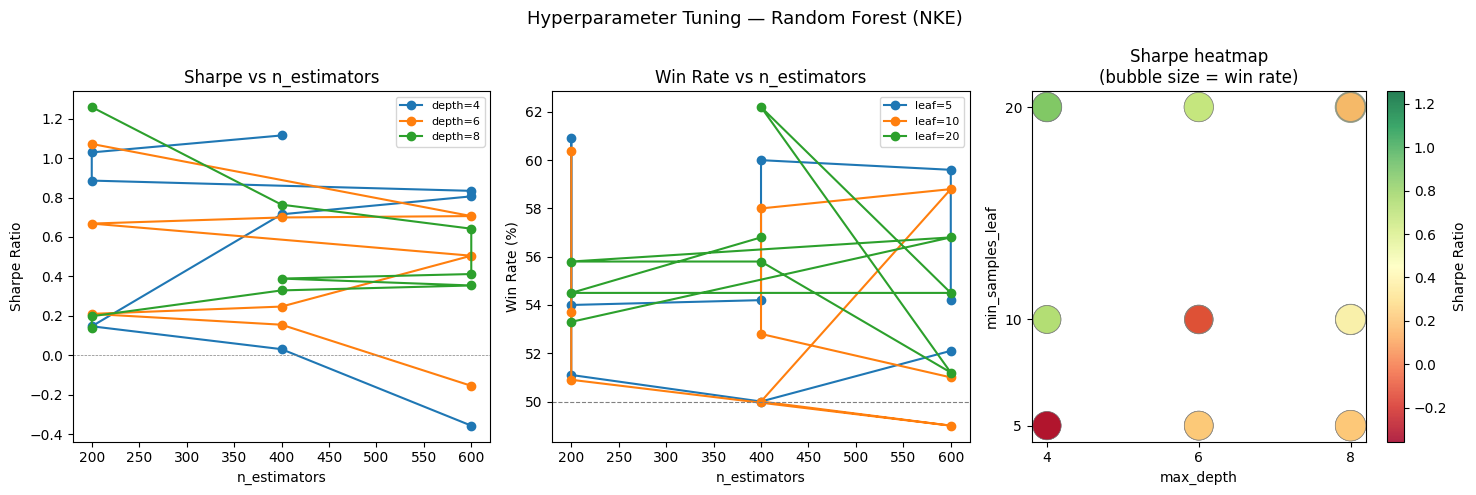

,n_estimators,max_depth,min_samples_leaf,Sharpe Ratio,Win Rate (%),Total Return (%),Max Drawdown (%),Total Trades
0,200,8,10,1.259,60.4,16.13,13.03,49
1,400,4,20,1.115,56.8,17.37,14.74,44
2,200,6,10,1.072,53.7,13.32,10.86,55
3,200,4,20,1.029,54.5,15.44,13.20,44
4,200,4,10,0.886,50.9,10.35,9.98,54
5,600,4,20,0.834,54.5,12.07,13.20,44
6,600,4,10,0.806,49.0,9.72,10.52,50
7,400,8,20,0.764,62.2,10.58,13.20,45
8,400,4,10,0.715,50.0,8.37,10.27,53
9,600,6,20,0.706,51.2,9.82,13.29,44


In [ ]:
# ─────────────────────────────────────────────
# 5b. HYPERPARAMETER TUNING — RANDOM FOREST
# ─────────────────────────────────────────────

import itertools
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Search grids — edit these to control what gets tested ────────────────────
GRID_N_ESTIMATORS     = [200, 400, 600]
GRID_MAX_DEPTH        = [4, 6, 8]
GRID_MIN_SAMPLES_LEAF = [5, 10, 20]

total_combinations = (len(GRID_N_ESTIMATORS) *
                      len(GRID_MAX_DEPTH) *
                      len(GRID_MIN_SAMPLES_LEAF))
print(f"Testing {total_combinations} hyperparameter combinations...")
print(f"Estimated runtime: ~{total_combinations * 2}–{total_combinations * 4} minutes\n")

hyperparam_results = []

for run_num, (n_est, depth, leaf) in enumerate(
    itertools.product(GRID_N_ESTIMATORS, GRID_MAX_DEPTH, GRID_MIN_SAMPLES_LEAF), 1
):
    print(f"[{run_num}/{total_combinations}] "
          f"n_estimators={n_est}, max_depth={depth}, min_samples_leaf={leaf}...",
          end=" ")

    try:
        # ── Build and train model ─────────────────────────────────────────────
        rf_tune = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42,
            n_jobs=-1,
        )
        model_tune = SKLearnModel(
            lags=10,
            lags_past_covariates=[-1, -2, -3, -5, -10, -20],
            model=rf_tune,
            output_chunk_length=FORECAST_HORIZON,
        )
        model_tune.fit(series=train_target, past_covariates=train_covs)

        # ── Historical forecasts ──────────────────────────────────────────────
        fc_tune = model_tune.historical_forecasts(
            series=target_series,
            past_covariates=covariates_series,
            start=test_target.start_time(),
            forecast_horizon=FORECAST_HORIZON,
            stride=1,
            retrain=False,
            last_points_only=True,
        )

        # ── Signals ───────────────────────────────────────────────────────────
        fc_s_tune = pd.Series(
            fc_tune.values().reshape(-1),
            index=fc_tune.time_index,
        )
        df_tune = df[["Close"]].copy()
        df_tune["Forecast_Return"] = fc_s_tune.reindex(df_tune.index).shift(FORECAST_HORIZON)
        df_cl_tune = df_tune.dropna()
        px_tune  = pd.Series(df_cl_tune["Close"].values,
                             index=pd.DatetimeIndex(df_cl_tune.index))
        sig_tune = pd.Series(df_cl_tune["Forecast_Return"].values,
                             index=pd.DatetimeIndex(df_cl_tune.index))
        thr_tune = sig_tune.std() * SIGNAL_THRESHOLD_MULT

        # ── Backtest ──────────────────────────────────────────────────────────
        pf_tune = vbt.Portfolio.from_signals(
            close=px_tune,
            entries=sig_tune > thr_tune,
            exits=sig_tune <= thr_tune,
            short_entries=sig_tune < -thr_tune,
            short_exits=sig_tune >= -thr_tune,
            init_cash=INIT_CASH,
            fees=0.001,
            freq="1D",
        )
        stats_tune = pf_tune.stats()

        sharpe   = round(float(stats_tune["Sharpe Ratio"]),    3)
        win_rate = round(float(stats_tune["Win Rate [%]"]),    1)
        ret      = round(float(stats_tune["Total Return [%]"]),2)
        drawdown = round(float(stats_tune["Max Drawdown [%]"]),2)
        trades   = int(stats_tune["Total Trades"])

        hyperparam_results.append({
            "n_estimators":     n_est,
            "max_depth":        depth,
            "min_samples_leaf": leaf,
            "Sharpe Ratio":     sharpe,
            "Win Rate (%)":     win_rate,
            "Total Return (%)": ret,
            "Max Drawdown (%)": drawdown,
            "Total Trades":     trades,
        })
        print(f"Sharpe={sharpe:.3f} | Win={win_rate:.1f}% | Return={ret:+.2f}%")

    except Exception as e:
        print(f"FAILED: {e}")
        hyperparam_results.append({
            "n_estimators": n_est, "max_depth": depth,
            "min_samples_leaf": leaf,
            "Sharpe Ratio": None, "Win Rate (%)": None,
            "Total Return (%)": None, "Max Drawdown (%)": None,
            "Total Trades": None,
        })

# ── Results table ─────────────────────────────────────────────────────────────
df_hp = (pd.DataFrame(hyperparam_results)
           .dropna(subset=["Sharpe Ratio"])
           .sort_values("Sharpe Ratio", ascending=False)
           .reset_index(drop=True))

print("\n" + "="*75)
print("  HYPERPARAMETER TUNING RESULTS — sorted by Sharpe Ratio")
print("="*75)
print(df_hp.to_string(index=True))
print("="*75)

# ── Best config ───────────────────────────────────────────────────────────────
best = df_hp.iloc[0]
print(f"""
Best configuration found:
  n_estimators     = {int(best['n_estimators'])}
  max_depth        = {int(best['max_depth'])}
  min_samples_leaf = {int(best['min_samples_leaf'])}
  Sharpe: {best['Sharpe Ratio']:.3f} | Win Rate: {best['Win Rate (%)']:.1f}% | Return: {best['Total Return (%)']:+.2f}%

To use this config, update cell_model with these values and re-run.
""")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Hyperparameter Tuning — Random Forest ({TICKER})", fontsize=13)

# Sharpe by max_depth
for depth in GRID_MAX_DEPTH:
    sub = df_hp[df_hp["max_depth"] == depth]
    axes[0].plot(sub["n_estimators"], sub["Sharpe Ratio"],
                 marker="o", label=f"depth={depth}")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].set_title("Sharpe vs n_estimators")
axes[0].legend(fontsize=8)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Win rate by min_samples_leaf
for leaf in GRID_MIN_SAMPLES_LEAF:
    sub = df_hp[df_hp["min_samples_leaf"] == leaf]
    axes[1].plot(sub["n_estimators"], sub["Win Rate (%)"],
                 marker="o", label=f"leaf={leaf}")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Win Rate (%)")
axes[1].set_title("Win Rate vs n_estimators")
axes[1].legend(fontsize=8)
axes[1].axhline(50, color="gray", linewidth=0.8,
                linestyle="--", label="50% baseline")

# Sharpe heatmap scatter
scatter = axes[2].scatter(
    df_hp["max_depth"],
    df_hp["min_samples_leaf"],
    c=df_hp["Sharpe Ratio"],
    s=df_hp["Win Rate (%)"] * 8,
    cmap="RdYlGn",
    edgecolors="gray",
    linewidths=0.5,
    alpha=0.85,
)
plt.colorbar(scatter, ax=axes[2], label="Sharpe Ratio")
axes[2].set_xlabel("max_depth")
axes[2].set_ylabel("min_samples_leaf")
axes[2].set_title("Sharpe heatmap\n(bubble size = win rate)")
axes[2].set_xticks(GRID_MAX_DEPTH)
axes[2].set_yticks(GRID_MIN_SAMPLES_LEAF)

plt.tight_layout()
plt.show()

display(df_hp)


## 5d. NLP vs Price-Only Comparison

This cell runs the model twice using identical hyperparameters and settings:  
once using **only the 7 price/technical features** and once using **all 18 features** (price + NLP).  
The difference in backtest performance directly measures the value added by the NLP sentiment signals.  

This is the core academic contribution of the project — demonstrating that integrating  
textual signals meaningfully improves predictive performance over a price-only baseline.


Running NLP vs Price-Only comparison (2 model trains)...

── Price features only (7 features) ──────────────────────────────
  Sharpe:   0.421
  Win Rate: 57.4%
  Return:   +4.47%
  Drawdown: 15.65%
  Trades:   55

── Price + NLP features (18 features) ──────────────────────────────
  Sharpe:   1.259
  Win Rate: 60.4%
  Return:   +16.13%
  Drawdown: 13.03%
  Trades:   49

  NLP vs PRICE-ONLY COMPARISON — NKE (2020-01-01 → 2023-12-31)
                      Features  Sharpe Ratio  Win Rate (%)  Total Return (%)  B&H Return (%)  Max Drawdown (%)  Profit Factor  Total Trades
Configuration                                                                                                                              
Price features only          7         0.421          57.4              4.47           -12.5             15.65          1.095            55
Price + NLP features        18         1.259          60.4             16.13           -12.5             13.03          1.477            49
  

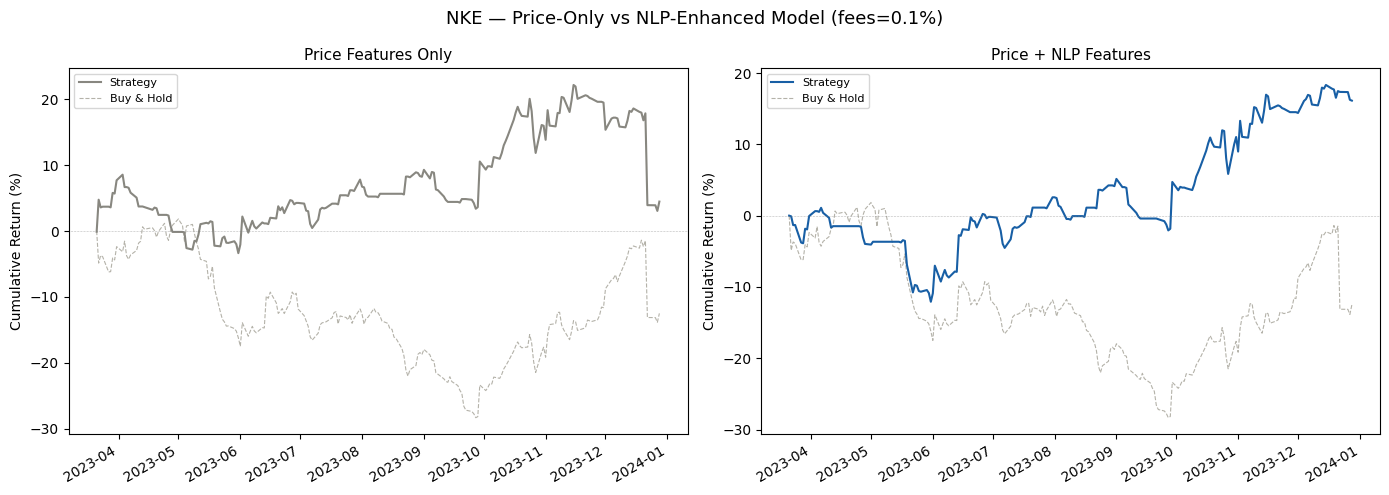

,Features,Sharpe Ratio,Win Rate (%),Total Return (%),B&H Return (%),Max Drawdown (%),Profit Factor,Total Trades
Configuration,,,,,,,,
Price features only,7,0.421,57.4,4.47,-12.5,15.65,1.095,55
Price + NLP features,18,1.259,60.4,16.13,-12.5,13.03,1.477,49


In [ ]:
# ─────────────────────────────────────────────
# 5d. NLP vs PRICE-ONLY COMPARISON
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

def run_feature_comparison(use_nlp: bool, label: str):
    """
    Run the full model → backtest pipeline with either:
      - Price features only (use_nlp=False): 7 features
      - All features     (use_nlp=True):  18 features (price + NLP)
    Returns a dict of backtest stats and the portfolio object for plotting.
    """
    # ── Select feature set ────────────────────────────────────────────────────
    price_cols = [
        "RangePct", "OC_Pct", "LogVol",
        "Ret_5d_mean", "Ret_20d_mean",
        "Ret_5d_vol",  "Ret_20d_vol",
    ]
    nlp_cols = [
        "news_sentiment", "news_ema5",     "news_momentum",
        "sports_sentiment","sports_ema5",  "sports_momentum",
        "earnings_sentiment", "earnings_ema5",
        "trends_score", "trends_ema5", "trends_momentum",
    ]

    feature_cols = price_cols + nlp_cols if use_nlp else price_cols
    n_features   = len(feature_cols)

    print(f"\n── {label} ({n_features} features) ──────────────────────────────")

    # ── Select rows — data already scaled by cell_merge, no re-scaling needed ──
    df_cmp = df[feature_cols + ["FwdReturn_1d", "Close"]].dropna().copy()

    # ── Darts time series ─────────────────────────────────────────────────────
    from darts import TimeSeries
    tgt_cmp = TimeSeries.from_dataframe(
        df_cmp, value_cols="FwdReturn_1d", fill_missing_dates=False
    )
    cov_cmp = TimeSeries.from_dataframe(
        df_cmp, value_cols=feature_cols, fill_missing_dates=False
    )
    tr_tgt_cmp, te_tgt_cmp = tgt_cmp.split_before(TRAIN_SPLIT)
    tr_cov_cmp, _           = cov_cmp.split_before(TRAIN_SPLIT)

    # ── Train model (same hyperparameters as main run) ────────────────────────
    from sklearn.ensemble import RandomForestRegressor
    from darts.models import SKLearnModel
    rf_cmp = RandomForestRegressor(
        n_estimators=200, max_depth=8,
        min_samples_leaf=10, random_state=42, n_jobs=-1,
    )
    mdl_cmp = SKLearnModel(
        lags=10,
        lags_past_covariates=[-1, -2, -3, -5, -10, -20],
        model=rf_cmp,
        output_chunk_length=FORECAST_HORIZON,
    )
    mdl_cmp.fit(series=tr_tgt_cmp, past_covariates=tr_cov_cmp)

    # ── Historical forecasts ──────────────────────────────────────────────────
    fc_cmp = mdl_cmp.historical_forecasts(
        series=tgt_cmp, past_covariates=cov_cmp,
        start=te_tgt_cmp.start_time(),
        forecast_horizon=FORECAST_HORIZON,
        stride=1, retrain=False, last_points_only=True,
    )

    # ── Signals ───────────────────────────────────────────────────────────────
    fc_s_cmp = pd.Series(fc_cmp.values().reshape(-1), index=fc_cmp.time_index)
    df_cmp["Forecast_Return"] = fc_s_cmp.reindex(df_cmp.index).shift(FORECAST_HORIZON)
    df_cl_cmp  = df_cmp[["Close", "Forecast_Return"]].dropna()
    px_cmp     = pd.Series(df_cl_cmp["Close"].values,
                           index=pd.DatetimeIndex(df_cl_cmp.index))
    sig_cmp    = pd.Series(df_cl_cmp["Forecast_Return"].values,
                           index=pd.DatetimeIndex(df_cl_cmp.index))
    thr_cmp    = sig_cmp.std() * SIGNAL_THRESHOLD_MULT

    # ── Backtest ──────────────────────────────────────────────────────────────
    pf_cmp = vbt.Portfolio.from_signals(
        close=px_cmp,
        entries=sig_cmp > thr_cmp,
        exits=sig_cmp <= thr_cmp,
        short_entries=sig_cmp < -thr_cmp,
        short_exits=sig_cmp >= -thr_cmp,
        init_cash=INIT_CASH,
        fees=0.001,       # match cell_backtest for a fair comparison
        freq="1D",
    )
    stats_cmp = pf_cmp.stats()
    bh_ret    = (px_cmp.iloc[-1] / px_cmp.iloc[0] - 1) * 100

    result = {
        "Configuration":    label,
        "Features":         n_features,
        "Sharpe Ratio":     round(float(stats_cmp["Sharpe Ratio"]),    3),
        "Win Rate (%)":     round(float(stats_cmp["Win Rate [%]"]),    1),
        "Total Return (%)": round(float(stats_cmp["Total Return [%]"]),2),
        "B&H Return (%)":   round(bh_ret,                             2),
        "Max Drawdown (%)": round(float(stats_cmp["Max Drawdown [%]"]),2),
        "Profit Factor":    round(float(stats_cmp["Profit Factor"]),   3),
        "Total Trades":     int(stats_cmp["Total Trades"]),
    }

    print(f"  Sharpe:   {result['Sharpe Ratio']:.3f}")
    print(f"  Win Rate: {result['Win Rate (%)']:.1f}%")
    print(f"  Return:   {result['Total Return (%)']:+.2f}%")
    print(f"  Drawdown: {result['Max Drawdown (%)']:.2f}%")
    print(f"  Trades:   {result['Total Trades']}")

    return result, pf_cmp, px_cmp


# ── Run both configurations ───────────────────────────────────────────────────
print("Running NLP vs Price-Only comparison (2 model trains)...")

res_price, pf_price, px_price = run_feature_comparison(
    use_nlp=False, label="Price features only"
)
res_nlp, pf_nlp, px_nlp = run_feature_comparison(
    use_nlp=True, label="Price + NLP features"
)

# ── Buy-and-hold benchmark ────────────────────────────────────────────────────
bh_return = res_price["B&H Return (%)"]  # same for both (same price series)

# ── Comparison table ──────────────────────────────────────────────────────────
df_comparison = pd.DataFrame([res_price, res_nlp]).set_index("Configuration")

print("\n" + "="*70)
print(f"  NLP vs PRICE-ONLY COMPARISON — {TICKER} ({START_DATE} → {END_DATE})")
print("="*70)
print(df_comparison.to_string())
print("="*70)
print(f"  Buy & Hold benchmark: {bh_return:+.2f}%")
print("="*70)

# ── Delta row ─────────────────────────────────────────────────────────────────
sharpe_delta  = res_nlp["Sharpe Ratio"]     - res_price["Sharpe Ratio"]
winrate_delta = res_nlp["Win Rate (%)"]     - res_price["Win Rate (%)"]
return_delta  = res_nlp["Total Return (%)"] - res_price["Total Return (%)"]
dd_delta      = res_nlp["Max Drawdown (%)"] - res_price["Max Drawdown (%)"]

print(f"""
NLP signal contribution:
  Sharpe improvement:    {sharpe_delta:+.3f}
  Win rate improvement:  {winrate_delta:+.1f} percentage points
  Return improvement:    {return_delta:+.2f} percentage points
  Drawdown change:       {dd_delta:+.2f} percentage points
""")

# ── Summary table formatted for poster / report ───────────────────────────────
print("\nFormatted comparison table (for poster/report):")
print(f"{'Metric':<25} {'Price Only':>15} {'Price + NLP':>15} {'Difference':>12}")
print("-" * 70)
metrics = [
    ("Sharpe Ratio",     res_price["Sharpe Ratio"],     res_nlp["Sharpe Ratio"],     True),
    ("Win Rate (%)",     res_price["Win Rate (%)"],     res_nlp["Win Rate (%)"],     True),
    ("Total Return (%)", res_price["Total Return (%)"], res_nlp["Total Return (%)"], True),
    ("Max Drawdown (%)", res_price["Max Drawdown (%)"], res_nlp["Max Drawdown (%)"], False),
    ("Profit Factor",    res_price["Profit Factor"],    res_nlp["Profit Factor"],    True),
    ("Total Trades",     res_price["Total Trades"],     res_nlp["Total Trades"],     None),
    ("B&H Benchmark (%)", bh_return,                   bh_return,                   None),
]
for name, v_price, v_nlp, higher_better in metrics:
    diff = v_nlp - v_price if higher_better is not None else 0
    diff_str = f"{diff:+.3f}" if higher_better is not None else "—"
    print(f"{name:<25} {str(v_price):>15} {str(v_nlp):>15} {diff_str:>12}")

# ── Side-by-side equity curve plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"{TICKER} — Price-Only vs NLP-Enhanced Model (fees=0.1%)",
    fontsize=13
)

for ax, pf_plot, px_plot, title, color in [
    (axes[0], pf_price, px_price, "Price Features Only",    "#888780"),
    (axes[1], pf_nlp,   px_nlp,   "Price + NLP Features",   "#185FA5"),
]:
    cum_strat = pf_plot.value() / INIT_CASH * 100 - 100
    cum_bh    = (px_plot / px_plot.iloc[0] * 100) - 100

    ax.plot(cum_strat.index, cum_strat.values,
            color=color, linewidth=1.5, label="Strategy", zorder=2)
    ax.plot(cum_bh.index, cum_bh.values,
            color="#B4B2A9", linewidth=0.8, linestyle="--",
            label="Buy & Hold", zorder=1)
    ax.axhline(0, color="gray", linewidth=0.4, linestyle=":")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Cumulative Return (%)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

display(df_comparison)


## 5. Feature Importance

Inspect how much each feature contributes to the model.  
A high importance for NLP features means sentiment is genuinely predictive.


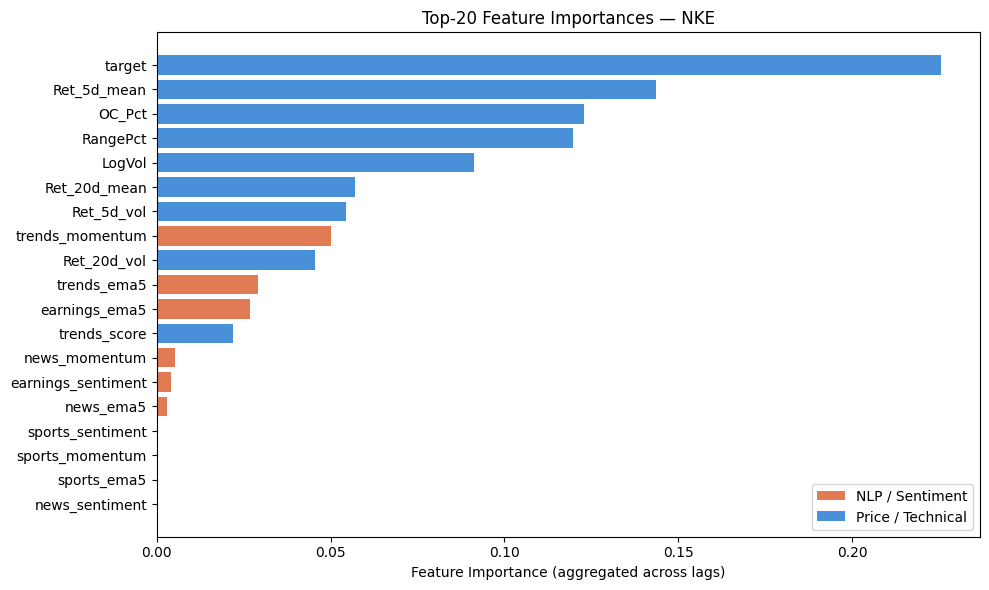


Top features:
base_feature
target             0.225538
Ret_5d_mean        0.143682
OC_Pct             0.122835
RangePct           0.119612
LogVol             0.091142
Ret_20d_mean       0.057097
Ret_5d_vol         0.054353
trends_momentum    0.050041
Ret_20d_vol        0.045517
trends_ema5        0.029023


In [ ]:
# ─────────────────────────────────────────────
# 6. FEATURE IMPORTANCE (Random Forest)
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Get the underlying fitted sklearn estimator
rf_fitted   = model.model
importances = rf_fitted.feature_importances_

# SKLearnModel stores lags as a dict e.g. {"target": [-1,-2,-3,-4,-5]}
# Use the actual feature names from the fitted estimator if available
try:
    feature_names = rf_fitted.feature_names_in_.tolist()
except AttributeError:
    # Manually reconstruct if feature_names_in_ not set
    target_lags = model.lags.get("target", [])
    cov_lags    = model.lags.get("past", [-1, -2, -5, -10, -20])

    target_lag_names = [f"target_lag{abs(l)}" for l in target_lags]
    cov_lag_names = [
        f"{col}_lag{abs(l)}"
        for l in cov_lags
        for col in ALL_FEATURE_COLS
    ]
    feature_names = target_lag_names + cov_lag_names

# Trim to the length of importances in case of mismatch
n = min(len(importances), len(feature_names))
feature_names = feature_names[:n]
importances   = importances[:n]

# Aggregate by base feature name (strip the _lagN suffix)
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .assign(base_feature=lambda d: d["feature"].str.rsplit("_lag", n=1).str[0])
    .groupby("base_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

# ── Plot top-20 ─────────────────────────────────────────────────────────────
top20  = imp_df.head(20)
colors = [
    "#E07B54" if any(k in f for k in ["sentiment", "ema5", "momentum"])
    else "#4A90D9"
    for f in top20.index
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel("Feature Importance (aggregated across lags)")
ax.set_title(f"Top-20 Feature Importances — {TICKER}")
ax.legend(handles=[
    Patch(facecolor="#E07B54", label="NLP / Sentiment"),
    Patch(facecolor="#4A90D9", label="Price / Technical"),
], loc="lower right")

plt.tight_layout()
plt.show()

print("\nTop features:")
print(imp_df.head(10).to_string())

## 6. Trading Signals & Backtest

In [ ]:
# ─────────────────────────────────────────────
# 7. ALIGN FORECASTS & BUILD TRADING SIGNALS
# ─────────────────────────────────────────────

forecast_s = pd.Series(
    forecast_series.values().reshape(-1),
    index=forecast_series.time_index,
)

# Shift by FORECAST_HORIZON to prevent look-ahead bias
df["Forecast_Return"] = forecast_s.reindex(df.index).shift(FORECAST_HORIZON)

df_clean = df[["Close", "Forecast_Return"]].dropna()
idx      = pd.DatetimeIndex(df_clean.index.values)

price  = pd.Series(df_clean["Close"].values,           index=idx)
signal = pd.Series(df_clean["Forecast_Return"].values, index=idx)

thr = signal.std() * SIGNAL_THRESHOLD_MULT
print(f"Signal threshold (±): {thr:.6f}")

long_entries  = signal > thr
long_exits    = signal <= thr
short_entries = signal < -thr
short_exits   = signal >= -thr

Signal threshold (±): 0.001430


In [ ]:
# ─────────────────────────────────────────────
# 8. BACKTEST WITH VECTORBT
# ─────────────────────────────────────────────

pf = vbt.Portfolio.from_signals(
    close=price,
    entries=long_entries,
    exits=long_exits,
    short_entries=short_entries,
    short_exits=short_exits,
    init_cash=INIT_CASH,
    fees=0.001,
    freq="1D",
)

print(f"\n{'='*45}")
print(f"  Backtest Results: {TICKER} ({START_DATE} → {END_DATE})")
print(f"  Forecast horizon: {FORECAST_HORIZON}-day | NLP: FinBERT + GDELT + EDGAR")
print(f"{'='*45}")
pf.stats()


  Backtest Results: NKE (2020-01-01 → 2023-12-31)
  Forecast horizon: 1-day | NLP: FinBERT + GDELT + EDGAR


,0
Start,2023-03-21 00:00:00
End,2023-12-28 00:00:00
Period,203 days 00:00:00
Start Value,10000.0
End Value,11612.959222
Total Return [%],16.129592
Benchmark Return [%],-12.496454
Max Gross Exposure [%],100.0
Total Fees Paid,996.92657
Max Drawdown [%],13.031807


In [ ]:
# ─────────────────────────────────────────────
# 9. PLOT EQUITY CURVE & TRADES
# ─────────────────────────────────────────────

import sys
IN_COLAB = "google.colab" in sys.modules
fig = pf.plot()

if IN_COLAB:
    import plotly.io as pio
    pio.renderers.default = "colab"
    fig.show()
else:
    fig.show()

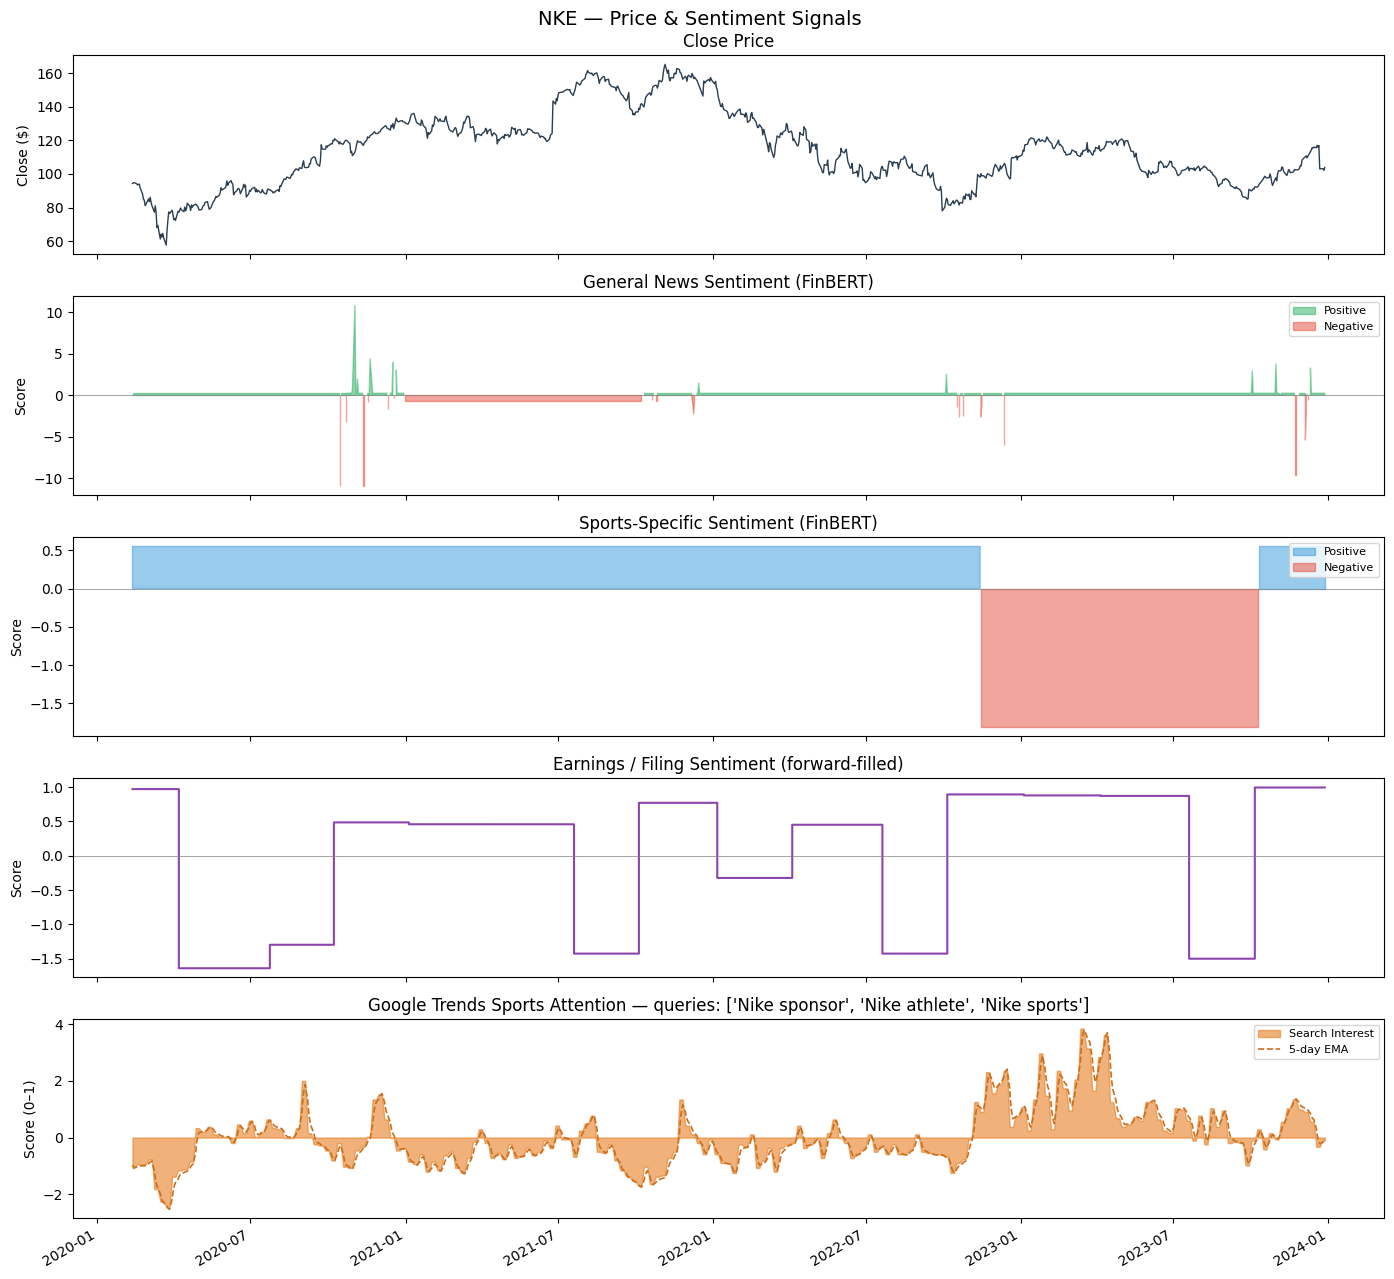

In [ ]:
# ─────────────────────────────────────────────
# 10. VISUALISE SENTIMENT OVER TIME
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
fig.suptitle(f"{TICKER} — Price & Sentiment Signals", fontsize=14)

# ── Panel 1: Price ───────────────────────────────────────────────────────────
axes[0].plot(df.index, df["Close"], color="#2C3E50", linewidth=1)
axes[0].set_ylabel("Close ($)")
axes[0].set_title("Close Price")

# ── Panel 2: General news ────────────────────────────────────────────────────
axes[1].fill_between(df.index, df["news_sentiment"], 0,
                     where=df["news_sentiment"] > 0, color="#27AE60", alpha=0.5, label="Positive")
axes[1].fill_between(df.index, df["news_sentiment"], 0,
                     where=df["news_sentiment"] < 0, color="#E74C3C", alpha=0.5, label="Negative")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("Score")
axes[1].set_title("General News Sentiment (FinBERT)")
axes[1].legend(loc="upper right", fontsize=8)

# ── Panel 3: Sports news ─────────────────────────────────────────────────────
axes[2].fill_between(df.index, df["sports_sentiment"], 0,
                     where=df["sports_sentiment"] > 0, color="#3498DB", alpha=0.5, label="Positive")
axes[2].fill_between(df.index, df["sports_sentiment"], 0,
                     where=df["sports_sentiment"] < 0, color="#E74C3C", alpha=0.5, label="Negative")
axes[2].axhline(0, color="gray", linewidth=0.5)
axes[2].set_ylabel("Score")
axes[2].set_title("Sports-Specific Sentiment (FinBERT)")
axes[2].legend(loc="upper right", fontsize=8)

# ── Panel 4: Earnings ────────────────────────────────────────────────────────
axes[3].step(df.index, df["earnings_sentiment"], color="#8E44AD", linewidth=1.5, where="post")
axes[3].axhline(0, color="gray", linewidth=0.5)
axes[3].set_ylabel("Score")
axes[3].set_title("Earnings / Filing Sentiment (forward-filled)")

# ── Panel 5: Google Trends ───────────────────────────────────────────────────
axes[4].fill_between(df.index, df["trends_score"], 0,
                     color="#E67E22", alpha=0.6, label="Search Interest")
axes[4].plot(df.index, df["trends_ema5"], color="#CA6F1E", linewidth=1.2,
             linestyle="--", label="5-day EMA")
axes[4].set_ylabel("Score (0–1)")
axes[4].set_title(f"Google Trends Sports Attention — queries: {TRENDS_QUERIES}")
axes[4].legend(loc="upper right", fontsize=8)

axes[4].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 11. Sentiment Scores vs Stock Price

Each sentiment signal is plotted alongside the NKE closing price on a shared time axis.  
The left axis shows the EMA5-smoothed sentiment score; the right axis shows the raw Close price.  
This allows visual inspection of whether sentiment shifts precede, coincide with, or lag price movements —
a key question for evaluating the predictive value of each signal.


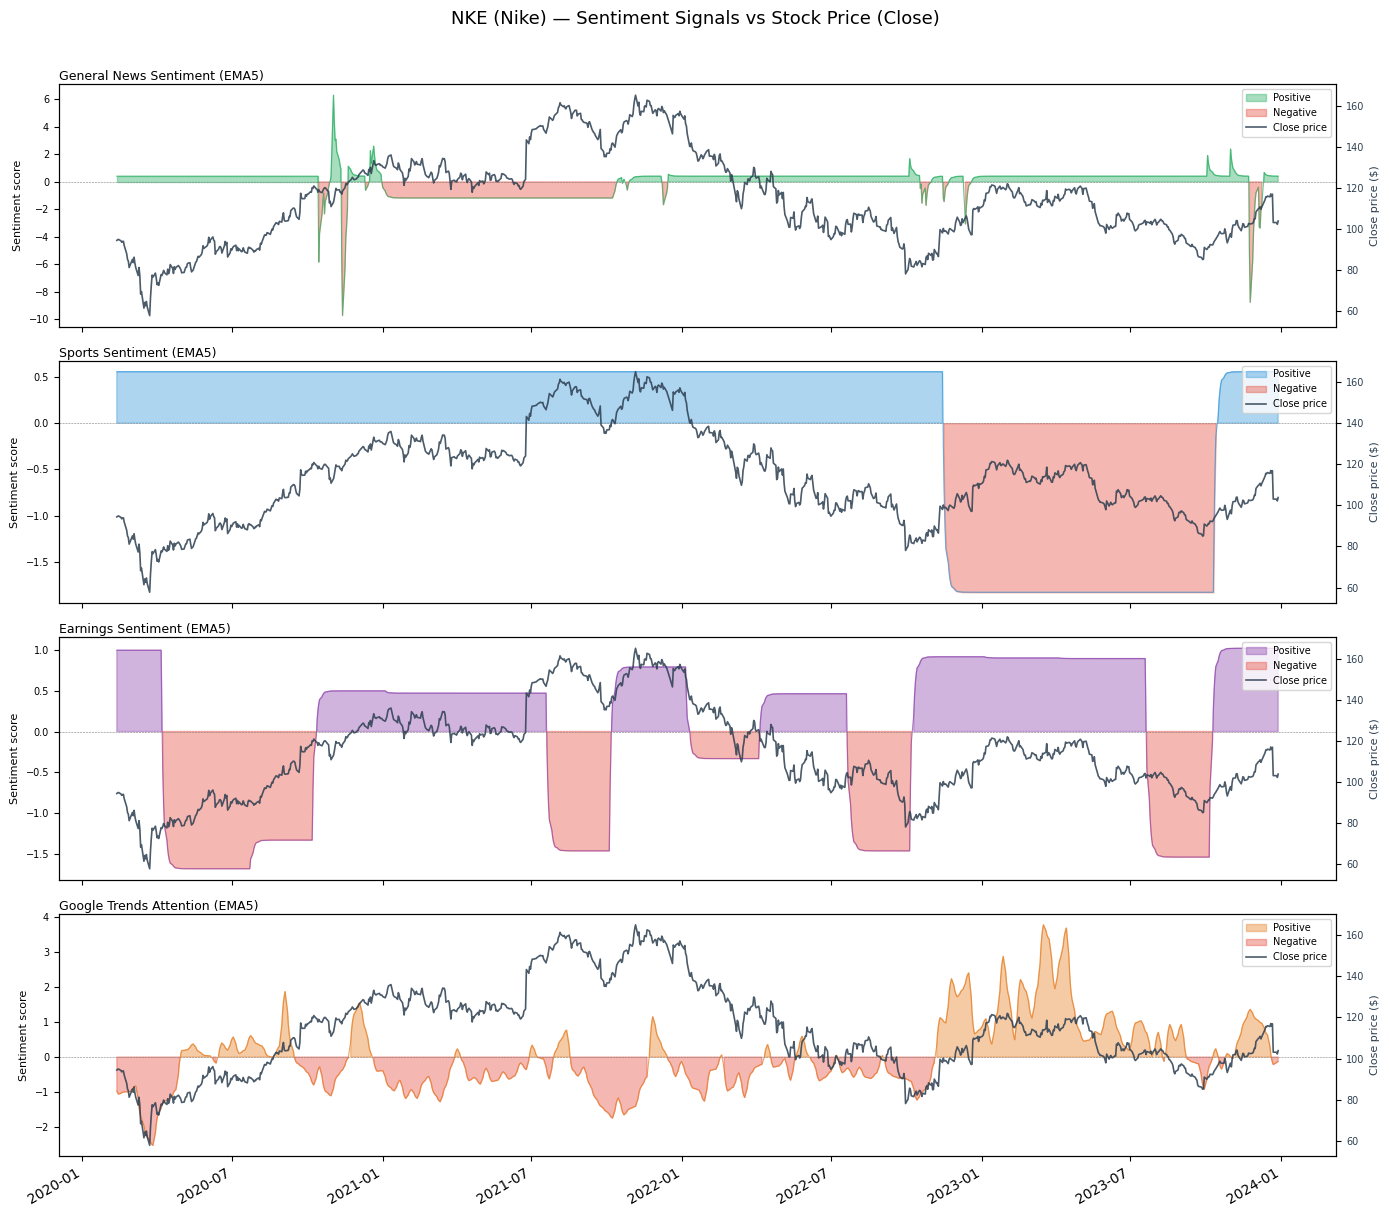

In [ ]:
# ─────────────────────────────────────────────
# 11. SENTIMENT SCORES vs STOCK PRICE
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Sentiment signals to plot (using EMA5 smoothed versions) ─────────────────
sentiment_signals = [
    ("news_ema5",      "#27AE60", "General News Sentiment (EMA5)"),
    ("sports_ema5",    "#3498DB", "Sports Sentiment (EMA5)"),
    ("earnings_ema5",  "#8E44AD", "Earnings Sentiment (EMA5)"),
    ("trends_ema5",    "#E67E22", "Google Trends Attention (EMA5)"),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    f"{TICKER} ({COMPANY}) — Sentiment Signals vs Stock Price (Close)",
    fontsize=13, y=1.01
)

for ax, (col, color, label) in zip(axes, sentiment_signals):
    # ── Right axis: stock Close price ────────────────────────────────────────
    ax2 = ax.twinx()
    ax2.plot(df.index, df["Close"], color="#2C3E50", linewidth=1.2,
             label="Close price", zorder=2, alpha=0.85)
    ax2.set_ylabel("Close price ($)", fontsize=8, color="#2C3E50")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="#2C3E50")

    # ── Left axis: sentiment score ───────────────────────────────────────────
    sent = df[col]
    ax.fill_between(df.index, sent, 0,
                    where=(sent >= 0), color=color, alpha=0.4, label="Positive")
    ax.fill_between(df.index, sent, 0,
                    where=(sent < 0),  color="#E74C3C", alpha=0.4, label="Negative")
    ax.plot(df.index, sent, color=color, linewidth=0.8, alpha=0.7)
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.set_ylabel("Sentiment score", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_title(label, fontsize=9, loc="left", pad=3)

    # ── Legend ───────────────────────────────────────────────────────────────
    sent_handles, sent_labels = ax.get_legend_handles_labels()
    price_handles, price_labels = ax2.get_legend_handles_labels()
    ax.legend(sent_handles + price_handles, sent_labels + price_labels,
              loc="upper right", fontsize=7)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [ ]:
#import os
#for f in [EARNINGS_CACHE, SPORTS_CACHE]:
    #if os.path.exists(f):
        #os.remove(f)
        #print(f"Deleted: {f}")

In [ ]:
#if os.path.exists(SPORTS_CACHE):
    #os.remove(SPORTS_CACHE)
    #print(f"Deleted: {SPORTS_CACHE}")

In [ ]:
#for path in [SPORTS_CACHE, NEWS_CACHE.replace(".parquet", "_raw.parquet")]:
    #if os.path.exists(path):
        #os.remove(path)
        #print(f"Deleted: {path}")
    #else:
        #print(f"Not found (ok): {path}")